# Superstore Sales Analytics – Exploratory Data Analysis (EDA)

This notebook explores the Superstore sales dataset to understand performance across categories, regions, segments, and discounts. The goal is to identify key patterns and insights that can inform business decisions and profitability strategies.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB


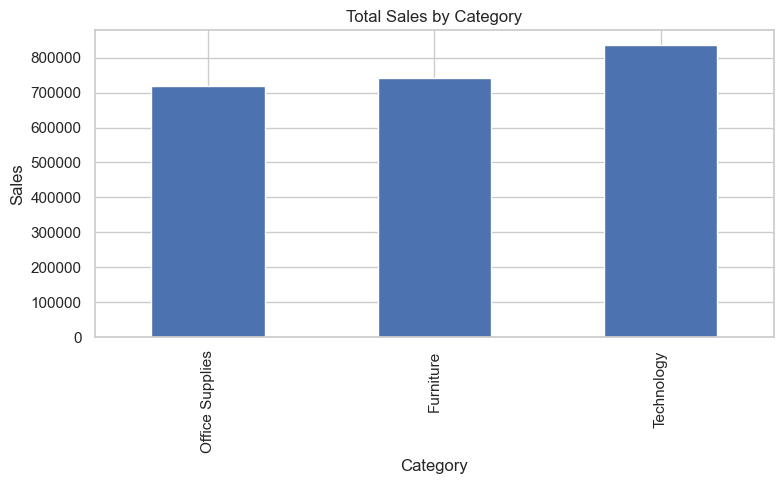

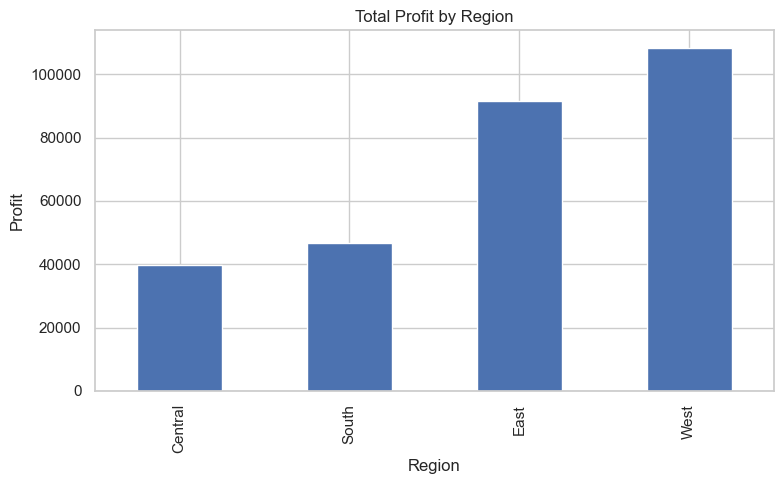

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# 1. Dataset Overview

# The dataset contains transactional sales data from a retail superstore, including information about orders, customers, products, regions and discounts.
df = pd.read_csv("../data/SampleSuperstore.csv")
df.head()

# 2. Data Structure and Quality Check:
# In this section, the structure of the dataset, data types, and missing values are examined to understand data quality, and identify any potential issues that may require cleaning.

df.info() # if anything needs to be cleaned

df.describe() # basic statistics for Sales, Profit, Quantity, Discount.

df.isna().sum() # a count of missing values in each column - understand the data phase

# Observations:

# The dataset contains information such as Ship Mode, Segment, Country, City, State, Region, Category, Sub-Category, Sales, Quantity, Discount, and Profit.
# Numeric columns like `Sales`, `Quantity`, `Discount`, and `Profit` will be key for analysis.
# Missing values (if any) will need to be handled appropriately, but overall the dataset appears structurally sound.

# 3. Feature Engineering:
# To better understand profitability, a new feature is created:'Profit Margin', which is defined as Profit divided by Sales for each transaction.

# Calculate profit margin:
df['Profit_Margin'] = df['Profit'] / df['Sales']
df[['Sales', 'Profit', 'Profit_Margin']].head() # creates a column showing how profitable each sale was

# 4. Descriptive Analysis:
# In this section, sales and profit have been aggregated across different business dimensions, such as Category, Region and Segment to identify high-performing areas.

# Business Insights:
# Sales by Category:
df.groupby('Category')['Sales'].sum().sort_values(ascending=False) # Technology, Furniture and Office Supplies sales are the best

# Profit by Region:
df.groupby('Region')['Profit'].sum().sort_values(ascending=False) # West is the region that performs best

# Sales by Segment:
df.groupby('Segment')['Sales'].sum().sort_values(ascending=False) # Consumer is the segment that performs best

# Observations:

# Certain product categories contribute disproportionately to total sales.
# Some regions may generate high sales but relatively lower profit, indicating potential cost or discount issues.
# Customer segments differ in their contribution to overall revenue.

# 5. Visual Analysis:

# We use visualizations to better understand the distribution of sales and profit across categories and regions.

# Sales by Category:
plt.figure(figsize=(8, 5))
df.groupby('Category')['Sales'].sum().sort_values().plot(kind='bar')
plt.title("Total Sales by Category")
plt.ylabel("Sales")
plt.xlabel("Category")
plt.tight_layout()
plt.savefig("../visualizations/sales_by_category.png", dpi=300, bbox_inches='tight')
plt.show()

# Profit by Region:
plt.figure(figsize=(8, 5))
df.groupby('Region')['Profit'].sum().sort_values().plot(kind='bar')
plt.title("Total Profit by Region")
plt.ylabel("Profit")
plt.xlabel("Region")
plt.tight_layout()
plt.savefig("../visualizations/profit_by_region.png", dpi=300, bbox_inches='tight')
plt.show()

# 6. Key Insights and Next Steps:

# Key Insights:

# Certain categories and regions drive the majority of sales and profit.
# Profit margin varies across products and regions, suggesting opportunities to optimize pricing or discount strategies.
# Customer segments show different purchasing behaviors, which could be leveraged for targeted marketing.

# Next Steps:

# Perform deeper analysis on the impact of discounts on profit.
# Use SQL to answer specific business questions (e.g., top customers, most profitable products).
# Build additional visualizations and dashboards to communicate findings to stakeholders.

